# Custom installers: your own hook for a node

Three extension points, from the least to the most work:

1. `rule={**BASE, 'ConvolutionBackward': ...}`: pick another built-in rule for a family, or pass your own rule function as the value.
2. `register_analyzer`: a fact that addresses some nodes (see `02_custom_analyzer`).
3. `register_installer(name, fn)`: replace the hook itself for every node whose autograd name contains `name`. This is the level below rules: `fn(node, config)` reads what the node saved, builds a hook that turns the arriving relevance into the relevance of the inputs, and returns the hook handle.

This notebook does 1 and 3.

In [1]:
import sys
sys.path.insert(0, '..')          # examples/showcase: _common
sys.path.insert(0, '../../..')    # repo root: autoLRP (or `pip install -e .`)
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import autoLRP
from autoLRP import LRPConfig, BASE, register_installer, INSTALLERS, explain, explain_summary
from autoLRP.backward.install import install_passthrough
from autoLRP.backward.lrp_utils import stabilize
torch.manual_seed(0)

model = nn.Sequential(
    nn.Conv2d(3, 8, 3, padding=1, bias=False), nn.ReLU(),
    nn.Conv2d(8, 16, 3, padding=1, bias=False), nn.ReLU(),
    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
    nn.Linear(16, 10, bias=False),
).eval()
img = torch.randn(1, 3, 32, 32)
with torch.no_grad():
    pred = model(img).argmax(-1).item()
print('predicted class:', pred)

predicted class: 1


## 1. A rule function as the config value

A linear-family rule is `fn(x, w, R_out, eps, fwd, bwd_a, bwd_b, **kwargs) -> (R_x, None)`: `fwd(x, w)` is the layer without bias, `bwd_a(w, s)` the gradient of that layer's output with respect to `x` for an output-shaped `s`. The epsilon rule is `x * bwd_a(w, R_out / stabilize(fwd(x, w)))`. Here is a "flat" rule that spreads each output's relevance evenly over its receptive field, ignoring the weights and the input, to show the shape of a rule. It conserves, since every output gives away exactly what it received.

In [2]:
def flat(x, w, R_out, eps, fwd, bwd_a, bwd_b):
    ones_w = torch.ones_like(w)
    n = fwd(torch.ones_like(x), ones_w)      # how many inputs each output reads
    return bwd_a(ones_w, R_out / n), None    # each output's relevance, shared evenly

cfg_flat = LRPConfig(rule={**BASE, 'ConvolutionBackward': flat})
rows = explain(model(autoLRP.tensor(img))[0, pred], cfg_flat)
print(explain_summary([r for r in rows if 'Conv' in r[0] or 'Mm' in r[0]]))

results = {}
for name, cfg in [('BASE', LRPConfig()), ('flat on conv', cfg_flat)]:
    x = autoLRP.tensor(img.clone())
    model(x)[0, pred].lrp(config=cfg)
    results[name] = x.relevance.clone()
    print(f'{name:14s} sum R = {float(x.relevance.sum()):+.4f}')

count  node                  key                   what
    2  ConvolutionBackward0  ConvolutionBackward   flat
    1  MmBackward0           MmBackward            epsilon


BASE           sum R = +1.0000
flat on conv   sum R = +1.0000


## 3. A custom installer

The default installer for `ReluBackward` lets all relevance through (`activation='passthrough'`). This one zeros relevance wherever the ReLU output was zero, so relevance flows only through units that fired. `ReluBackward0` saves its output as `_saved_result`; that is what the hook reads.

The hook signature is autograd's: `hook(grad_inputs, grad_outputs)` returns the tuple that replaces `grad_inputs`. `grad_outputs[0]` is the relevance arriving at the node's output.

In [3]:
@register_installer('ReluBackward')
def install_active_relu(node, config):
    out = getattr(node, '_saved_result', None)
    if out is None:
        return install_passthrough(node, config)
    mask = (out > 0).to(out.dtype)
    def _hook(gi, go, _m=mask):
        return (go[0] * _m,) + tuple(gi[1:])
    return node.register_hook(_hook)

print('registered:', INSTALLERS['ReluBackward'].__name__)

x_custom = autoLRP.tensor(img.clone())
model(x_custom)[0, pred].lrp()
print(f'with the custom ReLU installer: sum R = {float(x_custom.relevance.sum()):+.4f}')
rows = explain(model(autoLRP.tensor(img))[0, pred], LRPConfig())
print(explain_summary([r for r in rows if 'Relu' in r[0]]))

registered: install_active_relu
with the custom ReLU installer: sum R = +0.7233
count  node           key                   what
    2  ReluBackward0  None                  install_active_relu


In [4]:
# Put the default back. The registry is global; do this when the experiment is over.
register_installer('ReluBackward', install_passthrough)

x_default = autoLRP.tensor(img.clone())
model(x_default)[0, pred].lrp()
print(f'with the default passthrough:   sum R = {float(x_default.relevance.sum()):+.4f}')
print(f'max |difference| between the two maps: {float((x_custom.relevance - x_default.relevance).abs().max()):.3e}')

with the default passthrough:   sum R = +1.0000
max |difference| between the two maps: 2.294e-01


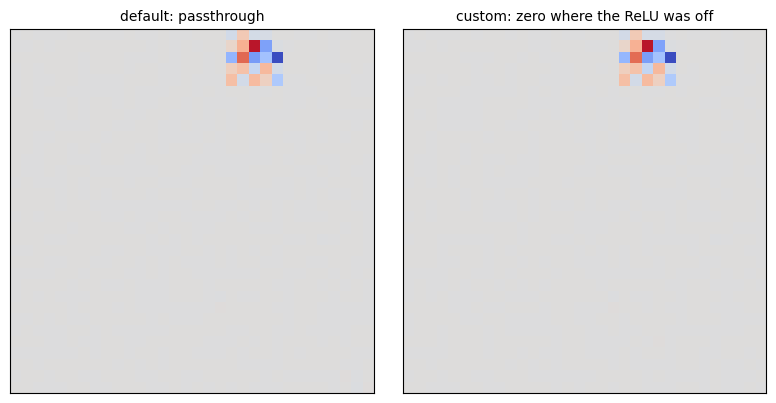

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (R, title) in zip(axes, [(x_default.relevance, 'default: passthrough'),
                                 (x_custom.relevance, 'custom: zero where the ReLU was off')]):
    m = R[0].sum(0).numpy()
    v = abs(m).max() + 1e-9
    ax.imshow(m, cmap='coolwarm', vmin=-v, vmax=v)
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Notes

- The strategy table that `register_installer` writes to is matched by the longest substring of the node name, so `'ReluBackward'` matches `ReluBackward0` and would also match a future `ReluBackward1`. Config keys are different: they are exact, a node name without its digit or a fact.
- `register_installer` wins over the `activation=`, `layernorm=` and `softmax=` fields: those fields only fill entries that still hold the default passthrough.
- An installer returns the hook handle, a list of handles, or `None` to let the native gradient run. It is called once per node per `.lrp()` call, after the analyzers, so it can read `autoLRP.node_facts(node)`.
- `explain` shows a custom installer by its function name, since it resolved no config entry.